# AIML Lab 3 - AI-Based Medical Diagnosis using a CNN

**Aim:** implement a simple AI-based medical diagnosis system using X-ray images
and a Convolutional Neural Network for image classification.

**Dataset:** PneumoniaMNIST chest X-rays (from MedMNIST v2, derived from the
Kaggle Chest X-Ray Pneumonia dataset). A balanced subset of 1000 images per
class is stored as PNGs in one folder per class:

```
dataset/
    NORMAL/
    PNEUMONIA/
```

**Steps covered:** load and display -> preprocess -> build and train a CNN ->
evaluate with accuracy and a confusion matrix.

## Part A - Load and Display the Dataset

### A1. Import the required libraries

In [1]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Fixed seeds so the results are reproducible
np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style="whitegrid")
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### A2. Load the X-ray dataset

`prepare_dataset.py` downloads the X-rays and writes them into one folder per
class. It runs automatically the first time, and is skipped afterwards.

In [2]:
DATASET_DIR = Path("dataset")
CLASSES = ["NORMAL", "PNEUMONIA"]   # NORMAL -> label 0, PNEUMONIA -> label 1

if not DATASET_DIR.exists():
    print("Dataset not found, preparing it now...")
    subprocess.run([sys.executable, "prepare_dataset.py"], check=True)

image_paths = {cls: sorted((DATASET_DIR / cls).glob("*.png")) for cls in CLASSES}

### A3. Number of images in each class

In [3]:
print("Number of Normal Images:   ", len(image_paths["NORMAL"]))
print("Number of Pneumonia Images:", len(image_paths["PNEUMONIA"]))
print("Total Images:              ", sum(len(p) for p in image_paths.values()))

Number of Normal Images:    1000
Number of Pneumonia Images: 1000
Total Images:               2000


### A4. Display a few sample images with their class labels

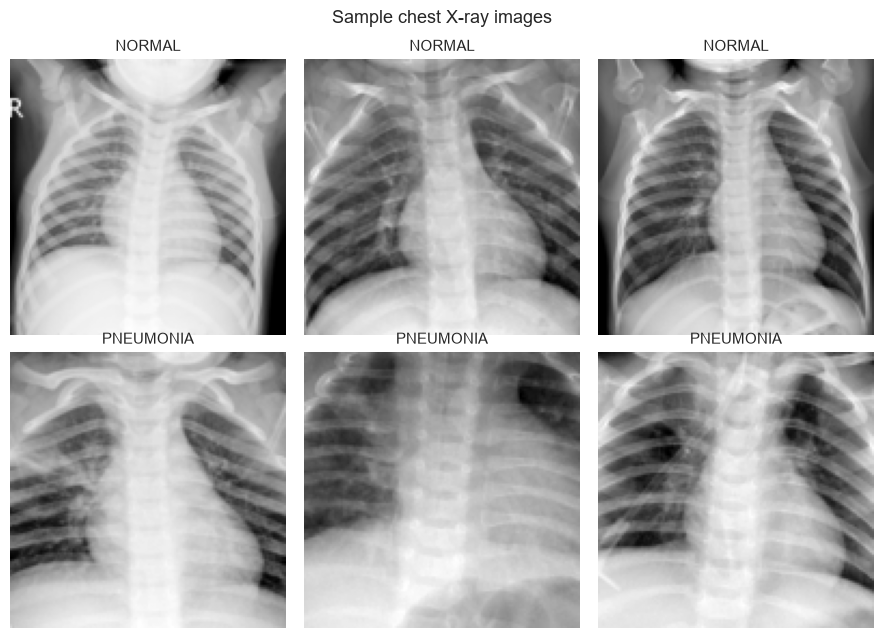

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6.5))

for row, cls in enumerate(CLASSES):
    for col in range(3):
        ax = axes[row, col]
        ax.imshow(Image.open(image_paths[cls][col]), cmap="gray")
        ax.set_title(cls, fontsize=11)
        ax.axis("off")

fig.suptitle("Sample chest X-ray images", fontsize=13)
plt.tight_layout()
plt.show()

## Part B - Preprocess the Images

Resize every image to 128 x 128, convert it to a numerical array, normalise the
pixel values to the range 0-1 and assign the class label.

In [5]:
IMG_SIZE = 128

X, y = [], []

for label, cls in enumerate(CLASSES):
    for path in image_paths[cls]:
        img = Image.open(path).convert("L").resize((IMG_SIZE, IMG_SIZE))   # grayscale + resize
        X.append(np.array(img))
        y.append(label)

X = np.array(X, dtype="float32") / 255.0            # normalise pixels: 0-255 -> 0-1
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)            # CNNs expect a channel dimension
y = np.array(y, dtype="int32")

print("Image Size:  ", f"{IMG_SIZE} x {IMG_SIZE}")
print("Data shape:  ", X.shape)
print("Label shape: ", y.shape)
print("Pixel range: ", X.min(), "to", X.max())

Image Size:   128 x 128
Data shape:   (2000, 128, 128, 1)
Label shape:  (2000,)
Pixel range:  0.0 to 1.0


### Divide the data into training and testing sets (80% / 20%)

`stratify=y` keeps the same class balance in both sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples: ", len(X_test))
print()
print("Training set - Normal:", int((y_train == 0).sum()), "| Pneumonia:", int((y_train == 1).sum()))
print("Testing set  - Normal:", int((y_test == 0).sum()), "| Pneumonia:", int((y_test == 1).sum()))

Training Samples: 1600
Testing Samples:  400

Training set - Normal: 800 | Pneumonia: 800
Testing set  - Normal: 200 | Pneumonia: 200


## Part C - Build and Train a Simple CNN

A basic CNN: two convolution + max pooling blocks, a flatten layer, one dense
layer and a single sigmoid output unit (binary classification).

In [7]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    layers.Conv2D(16, (3, 3), activation="relu"),   # convolution + ReLU
    layers.MaxPooling2D((2, 2)),                    # pooling

    layers.Conv2D(32, (3, 3), activation="relu"),   # convolution + ReLU
    layers.MaxPooling2D((2, 2)),                    # pooling

    layers.Flatten(),
    layers.Dense(64, activation="relu"),            # dense layer
    layers.Dense(1, activation="sigmoid"),          # output layer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,129 (7.05 MB)

 Trainable params: 1,848,129 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

### Train the model

In [9]:
EPOCHS = 5

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_split=0.2,     # 20% of the training data is held out for validation
    verbose=2,
)

Epoch 1/5


40/40 - 3s - 78ms/step - accuracy: 0.6617 - loss: 0.6029 - val_accuracy: 0.8719 - val_loss: 0.3530


Epoch 2/5


40/40 - 2s - 46ms/step - accuracy: 0.8750 - loss: 0.2980 - val_accuracy: 0.9000 - val_loss: 0.2554


Epoch 3/5


40/40 - 2s - 45ms/step - accuracy: 0.9148 - loss: 0.2256 - val_accuracy: 0.9219 - val_loss: 0.2080


Epoch 4/5


40/40 - 2s - 45ms/step - accuracy: 0.9320 - loss: 0.1935 - val_accuracy: 0.9156 - val_loss: 0.2250


Epoch 5/5


40/40 - 2s - 45ms/step - accuracy: 0.9352 - loss: 0.1753 - val_accuracy: 0.9250 - val_loss: 0.2087


### Test the model

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f} %")

Test Loss:     0.1692
Test Accuracy: 94.50 %


### Training accuracy graph

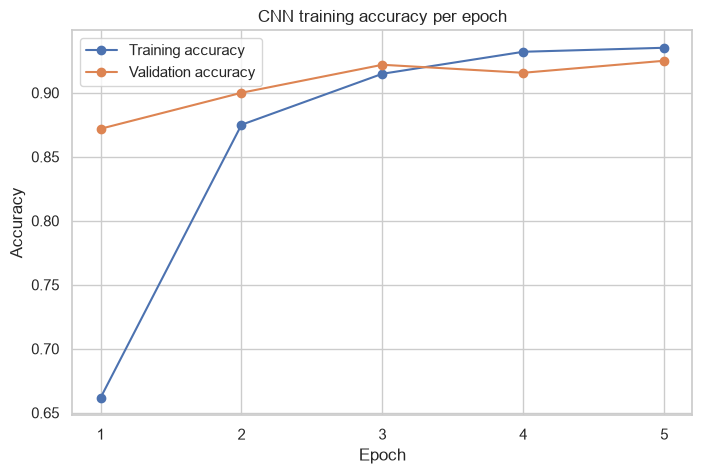

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), history.history["accuracy"], marker="o", label="Training accuracy")
plt.plot(range(1, EPOCHS + 1), history.history["val_accuracy"], marker="o", label="Validation accuracy")

plt.title("CNN training accuracy per epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.show()

## Part D - Evaluate and Predict

### D1. Generate predictions for the test images

In [12]:
# The sigmoid output is a probability; anything >= 0.5 is classified as Pneumonia
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype("int32")

print("First 10 predicted probabilities:", np.round(y_prob[:10], 3))
print("First 10 predicted labels:       ", y_pred[:10])
print("First 10 actual labels:          ", y_test[:10])

First 10 predicted probabilities: [0.011 0.003 0.97  0.007 0.002 0.55  0.934 0.002 0.001 0.956]
First 10 predicted labels:        [0 0 1 0 0 1 1 0 0 1]
First 10 actual labels:           [0 0 1 0 0 1 1 0 0 1]


### D2. Classification accuracy

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Correct Predictions: {int((y_pred == y_test).sum())} / {len(y_test)}")
print(f"Test Accuracy: {accuracy * 100:.2f} %")

Correct Predictions: 378 / 400
Test Accuracy: 94.50 %


### D3. Confusion matrix

In [14]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print()
print("True Negative  (Normal    predicted as Normal):   ", tn)
print("False Positive (Normal    predicted as Pneumonia):", fp)
print("False Negative (Pneumonia predicted as Normal):   ", fn)
print("True Positive  (Pneumonia predicted as Pneumonia):", tp)

Confusion Matrix:
[[198   2]
 [ 20 180]]

True Negative  (Normal    predicted as Normal):    198
False Positive (Normal    predicted as Pneumonia): 2
False Negative (Pneumonia predicted as Normal):    20
True Positive  (Pneumonia predicted as Pneumonia): 180


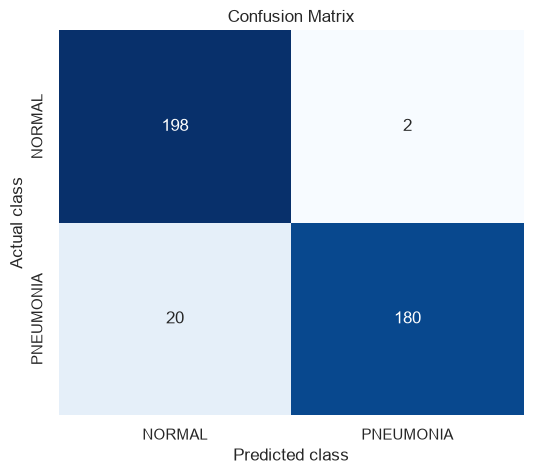

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASSES, yticklabels=CLASSES)

plt.title("Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()

In [16]:
print(classification_report(y_test, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

      NORMAL       0.91      0.99      0.95       200
   PNEUMONIA       0.99      0.90      0.94       200

    accuracy                           0.94       400
   macro avg       0.95      0.95      0.94       400
weighted avg       0.95      0.94      0.94       400



### D4. Display a few test images with their predicted class

In [17]:
sample_idx = np.random.choice(len(X_test), 6, replace=False)

for i in sample_idx:
    print(f"Actual: {CLASSES[y_test[i]]:<10} Predicted: {CLASSES[y_pred[i]]}")

Actual: NORMAL     Predicted: NORMAL
Actual: PNEUMONIA  Predicted: PNEUMONIA
Actual: NORMAL     Predicted: NORMAL
Actual: NORMAL     Predicted: NORMAL
Actual: NORMAL     Predicted: NORMAL
Actual: PNEUMONIA  Predicted: PNEUMONIA


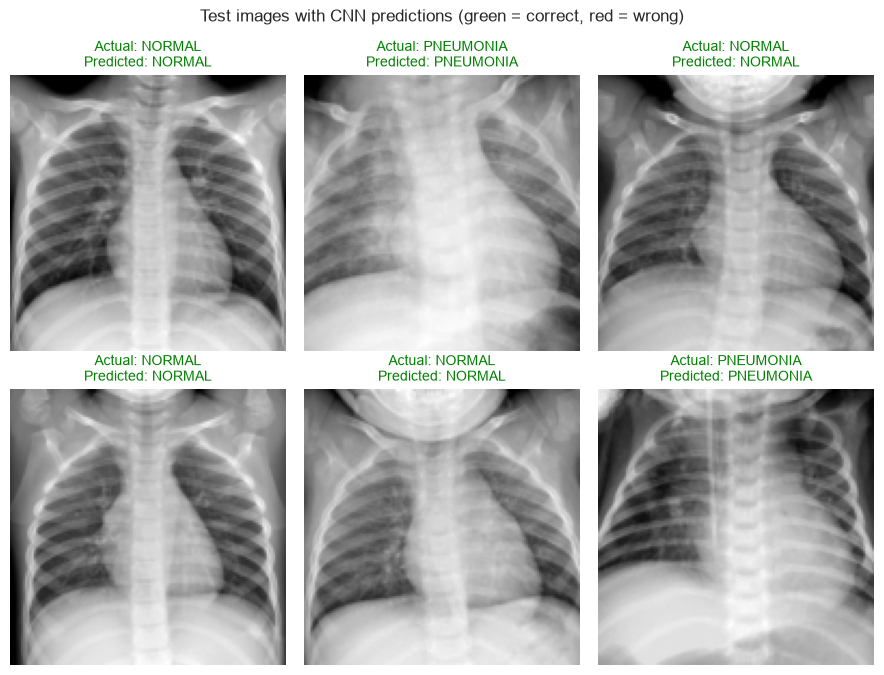

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(9, 7))

for ax, i in zip(axes.ravel(), sample_idx):
    actual, predicted = CLASSES[y_test[i]], CLASSES[y_pred[i]]
    correct = actual == predicted

    ax.imshow(X_test[i].squeeze(), cmap="gray")
    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}",
                 fontsize=10, color="green" if correct else "red")
    ax.axis("off")

fig.suptitle("Test images with CNN predictions (green = correct, red = wrong)", fontsize=12)
plt.tight_layout()
plt.show()

## Result

The AI-based medical image classification system was implemented using a simple
Convolutional Neural Network. The model was trained on chest X-ray images and
classifies them as **Normal** or **Pneumonia**. Its performance was evaluated
using accuracy and a confusion matrix.